In [3]:
import math 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
def f(x):
    return 3 * (x**2) - 4 * x + 5

In [5]:
f(3.0)

20.0

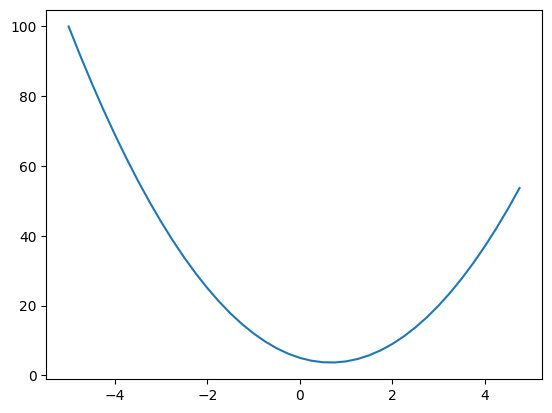

In [8]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [10]:
# Deriving the gradient using limits h-> 0

h = 0.00000001 #0.001
x = 3.0
d_fx = (f(x+h) - f(x)) / h
d_fx # Numerical approximation of the derivative at x=3.0

14.00000009255109

In [11]:
x = -3.0
d_fx = (f(x+h) - f(x)) / h
d_fx # Numerical approximation of the derivative at x=-3.0

-22.00000039920269

In [12]:
x = 2 / 3
d_fx = (f(x+h) - f(x)) / h
d_fx # Numerical approximation of the derivative at x=2/3

0.0

Multiple inputs

In [14]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
d


h = 0.0001
d_a = (((a+h)*b + c) - (a*b + c)) / h
d_a # Derivative of d with respect to a = b | b = -3.0

-3.000000000010772

Building NN datatypes

In [60]:
# Computational Graph we are building
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, _children=(self, other), _op='+') # Creating another Value object to hold the result, adding the data value
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, _children=(self, other), _op='*')
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        return Value(t, (self, ), 'tanh')

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
e = a * b; e.label='e'
c = Value(10.0, label='c')
d = e + c; d.label='d'
f = Value(-2.0, label='f')
L = d * f; L.label='L'
print(d, d.data, d._prev, d._op)

Value(data=4.0) 4.0 {Value(data=10.0), Value(data=-6.0)} +


In [45]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

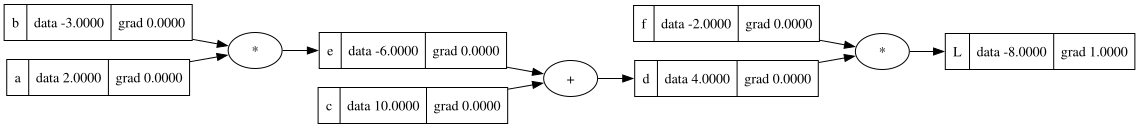

In [51]:
draw_dot(L)

Backpropagation

In [49]:
# We try to find derivative of L wrt weights rather than input data because that is constant and what we are trying to do is to optimize weights to minimize loss L

def lol():
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    e = a * b; e.label='e'
    c = Value(10.0, label='c')
    d = e + c; d.label='d'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

    h = 0.0001
    a = Value(2.0 + h, label='a')
    b = Value(-3.0, label='b')
    e = a * b; e.label='e'
    c = Value(10.0, label='c')
    d = e + c; d.label='d'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data

    return (L2 - L1) / h

lol() # Derivative of L wrt a

6.000000000021544

In [55]:
L.grad = 1.0
d.grad = f.data # found it by calculus or limit approach and hence setting up here
f.grad = d.data

In [56]:
dL_dc = 1
# dL_dc = DL_dd * dd_dc # Chain rule
# dL_da = dL_dd * dd_de * de_da
# dL_db = dL_dd * dd_de * de_db

# Plus nodes just pass the gradient to both children
# Multiplication nodes pass the gradient multiplied by the other child's data

c.grad = d.grad * 1.0
e.grad = d.grad * 1.0

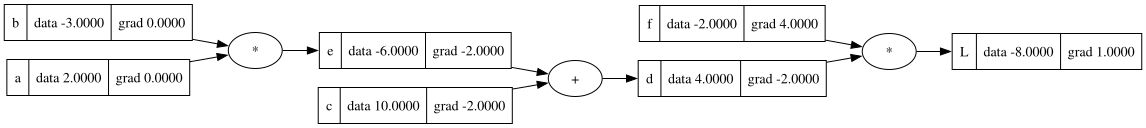

In [57]:
draw_dot(L)

In [ ]:
dL_de = -2.0
dL_da = dL_de * de_da # de_da = b.data = -3.0
dL_db = dL_de * de_da # de_db = a.data = 2.0

In [ ]:
# So all we are doing is applying chain rule at each node in the computational graph to get the gradients wrt each variable
# Take the children of each node and multiply their gradients by the local gradient at that node

### Creating a Multilayer Perceptron function

In [64]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias b
b = Value(6.8813735870195432, label='b')

# weighted sum
x1w1 = x1 * w1; x1w1.label='x1*w1'
x2w2 = x2 * w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label='n'
o = n.tanh(); o.label='o'

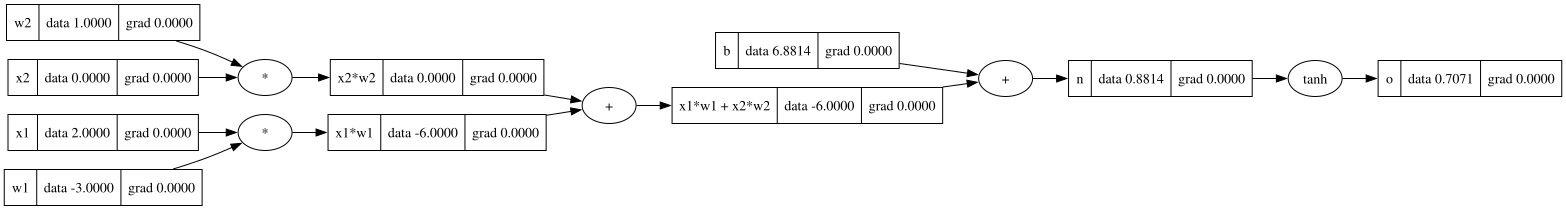

In [65]:
draw_dot(o)

In [66]:
# We want to know the gradient wrt weight

o.grad = 1

# local derivative of tanh wrt n
# d_tanh = 1 - tanh^2
# dO_dn = 1 - o**2

n.grad = 1 - o.data**2
b.grad = n.grad
x1w1x2w2.grad = n.grad
x1w1.grad = n.grad
x2w2.grad = n.grad
w1.grad = n.grad * x1.data
x1.grad = n.grad * w1.data

w2.grad = n.grad * x2.data
x2.grad = n.grad * w2.data

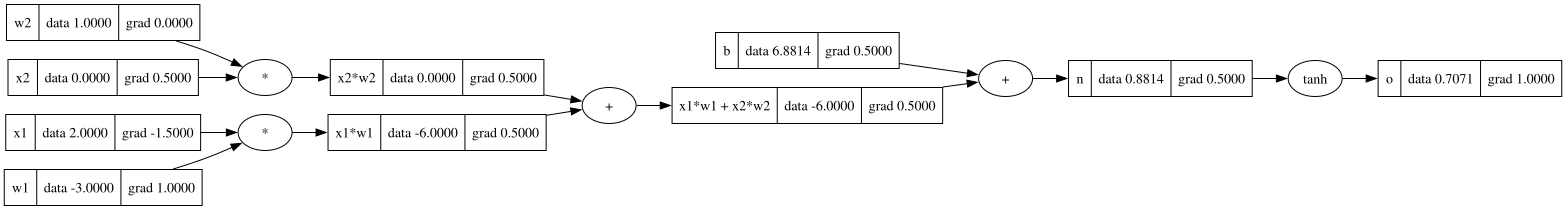

In [67]:
draw_dot(o)

In [131]:
# Integration of Backwas Propagation to calculate chain rule

# Computational Graph we are building
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, label={self.label})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # To support adding constants
        out = Value(self.data + other.data, _children=(self, other), _op='+') # Creating another Value object to hold the result, adding the data value

        def _backward():
            # Chain rule = local gradient * global gradient
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        # support int/float + Value (called when left operand doesn't handle the op)
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) # To support multiplying with constants
        out = Value(self.data * other.data, _children=(self, other), _op='*')

        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, _children=(self, ), _op=f'**{other}')

        def _backward():
            self.grad += out.grad * other * (self.data**(other -1))
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * other**-1

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += out.grad * (1 - t**2)

        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.grad * out.data # derivative of exp is exp itself

        out._backward = _backward
        return out

    def backward(self):
        # Topological order all of the children in the graph
        topo = []
        visited = set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)
        build(self)

        # Go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias b
b = Value(6.8813735870195432, label='b')

# weighted sum
x1w1 = x1 * w1; x1w1.label='x1*w1'
x2w2 = x2 * w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label='n'
o = n.tanh(); o.label='o'

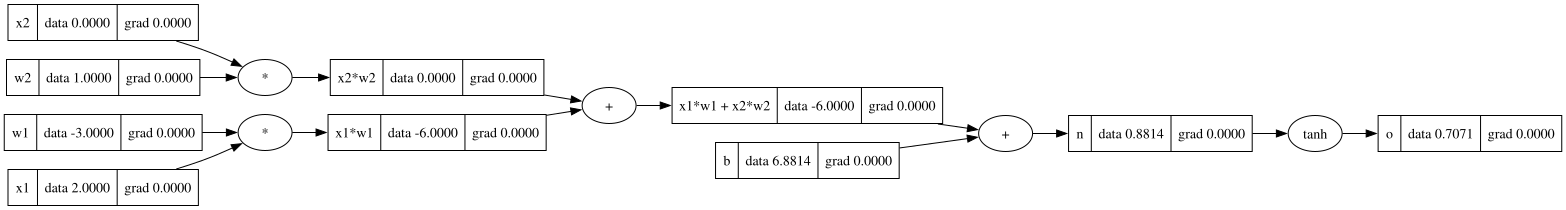

In [98]:
draw_dot(o)

#### We are essentially doing backward propagation recursively!!
#### We need a topological sort
#### Then we need to update weights in direction of gradient

In [74]:
# setting the base case
o.grad = 1.0
o._backward()

In [76]:
n._backward()

In [78]:
b._backward()

In [80]:
x1w1x2w2._backward()

In [82]:
x1w1._backward()

In [84]:
x2w2._backward()

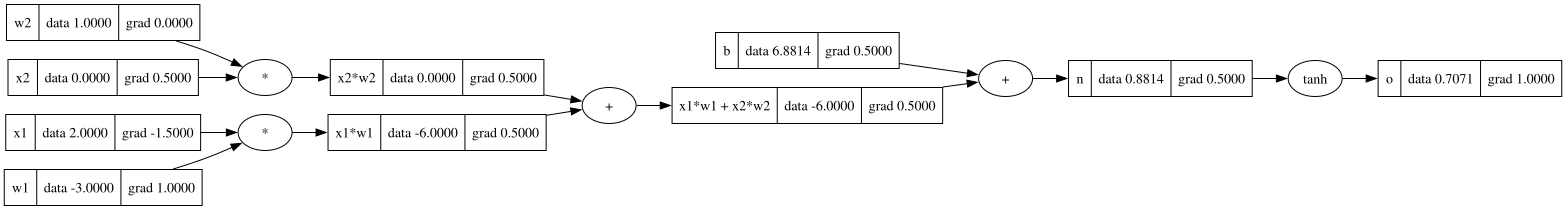

In [93]:
o.backward()
draw_dot(o)

## Bug Time

In [ ]:
b = a + a -> wrong gradient
c = a + b
d = a * c

Need to accumulate gradients for 'a' since it appears multiple times in the computational graph.

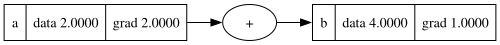

In [95]:
a = Value(2.0, label='a')
b = a + a; b.label='b'
b.backward()
draw_dot(b)

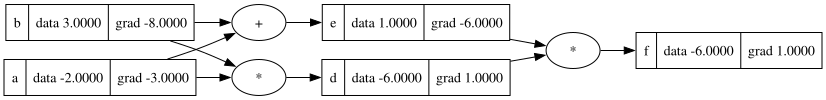

In [96]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label='d'
e = a + b; e.label='e'
f = d * e; f.label='f'

f.backward()
draw_dot(f)

### Multiplication

a / b
a * (1 / b)
a * (b**-1)

### PyTorch Implementation

In [107]:
import torch

# Micrograd uses scalar input values whereas PyTorch uses tensors even for scalars

x1 = torch.tensor([2.0], requires_grad=True, dtype=torch.float64)
x2 = torch.tensor([0.0], requires_grad=True, dtype=torch.float64)

w1 = torch.tensor([-3.0], requires_grad=True, dtype=torch.float64)
w2 = torch.tensor([1.0], requires_grad=True, dtype=torch.float64)
b = torch.tensor([6.8813735870195432], requires_grad=True, dtype=torch.float64)

x1w1 = x1 * w1
x2w2 = x2 * w2
n = x1w1 + x2w2 + b
o = torch.tanh(n)

o.backward()

In [108]:
print(f"x1.grad: {x1.grad}")
print(f"x2.grad: {x2.grad}")
print(f"w1.grad: {w1.grad}")
print(f"w2.grad: {w2.grad}")


x1.grad: tensor([-1.5000], dtype=torch.float64)
x2.grad: tensor([0.5000], dtype=torch.float64)
w1.grad: tensor([1.0000], dtype=torch.float64)
w2.grad: tensor([0.], dtype=torch.float64)


### Neuron Implmentation

In [118]:
import random

# A particular node in a neural network
class Neuron:

    # nin is number of inputs to the neuron
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    # nin is number of inputs to the layer
    # nout is number of neurons in the layer
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):

        # x is list of inputs
        outs = [n(x) for n in self.neurons]
        return outs if len(outs) > 1 else outs[0]

    def parameters(self):
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
        return params

class MLP:

    # nin is number of inputs
    # nouts is list of number of neurons in each layer
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] # Creating layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x) # Forwarding through each layer; output of one layer is input to next layer
        return x

    def parameters(self):
        params = []
        for layer in self.layers:
            params.extend(layer.parameters())
        return params

In [142]:
# Declare the architecture with number of neurons in each layer and inputs

x = [2.0, 3.0, -1.0]  # example input
mlp = MLP(3, [4, 4, 1])  # MLP with 3 inputs, hidden layer with 4 neurons, output layer with 1 neuron
mlp(x)

Value(data=0.9031634165827728, label=)

In [120]:
mlp.parameters()

[Value(data=-0.5016022911298896, label=),
 Value(data=-0.2186876380165963, label=),
 Value(data=0.8583519280924452, label=),
 Value(data=-0.6372246078029475, label=),
 Value(data=0.607315490499458, label=),
 Value(data=0.42114084103028215, label=),
 Value(data=0.8907947297498353, label=),
 Value(data=0.9716607717705399, label=),
 Value(data=-0.36306816512017437, label=),
 Value(data=0.39077859578473784, label=),
 Value(data=-0.09340379294214296, label=),
 Value(data=-0.030453529416121228, label=),
 Value(data=-0.8104575038340149, label=),
 Value(data=0.8667041340254502, label=),
 Value(data=0.45077527428721265, label=),
 Value(data=-0.695377250107228, label=),
 Value(data=-0.7775162519947891, label=),
 Value(data=-0.656329375128825, label=),
 Value(data=0.7807821323107755, label=),
 Value(data=-0.6879265181160485, label=),
 Value(data=0.009415365430768041, label=),
 Value(data=0.20976923408255232, label=),
 Value(data=-0.9337242966641539, label=),
 Value(data=-0.7807162308280866, label

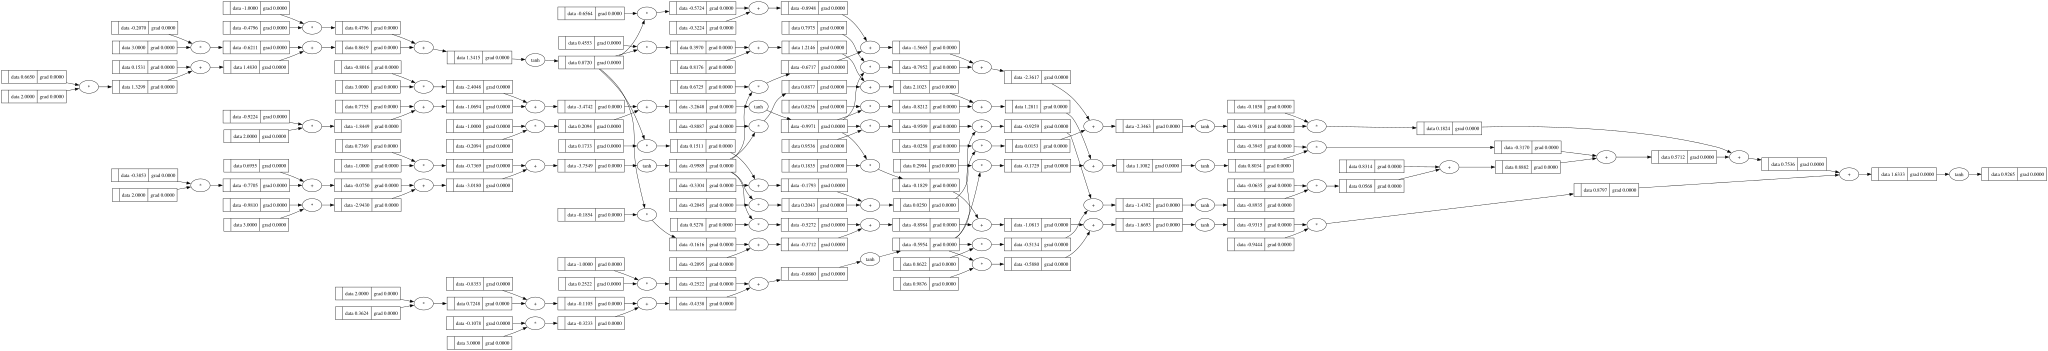

In [117]:
draw_dot(mlp(x))

### Creating a tiny dataset 

In [140]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.0, 0.0, 1.0],
    [1.0, 1.0, 1.0],
]

ys = [Value(1.0), Value(-1.0), Value(-1.0), Value(1.0)]  # example targets
ypred = [mlp(x) for x in xs]

# Use a Value(0.0) start so Python's sum doesn't try to add an int to a Value
loss = sum(((yout - ygt)**2 for yout, ygt in zip(ypred, ys)), Value(0.0))
loss.backward()

In [134]:
mlp.layers[0].neurons[0].w[0].grad

0.12398777924974369

In [130]:
for p in mlp.parameters():
    p.data -= 0.01 * p.grad  # SGD step
    p.grad = 0.0  # reset gradient to 0

In [143]:
losses = []
for k in range(100):
    ypred = [mlp(x) for x in xs]
    loss = sum(((yout - ygt)**2) for yout, ygt in zip(ypred, ys))
    loss.backward()
    for p in mlp.parameters():
        p.data -= 0.01 * p.grad
        p.grad = 0.0
    if k % 10 == 0:
        print(f"Step {k} loss: {loss.data}")
    losses.append(loss.data)

Step 0 loss: 6.454804184309146
Step 10 loss: 2.2044739809317813
Step 20 loss: 0.832990897922931
Step 30 loss: 0.40613820050582583
Step 40 loss: 0.24878523194344218
Step 50 loss: 0.17299140533870155
Step 60 loss: 0.13003293272906946
Step 70 loss: 0.10294529145558029
Step 80 loss: 0.08454363024945079
Step 90 loss: 0.07134046603657644


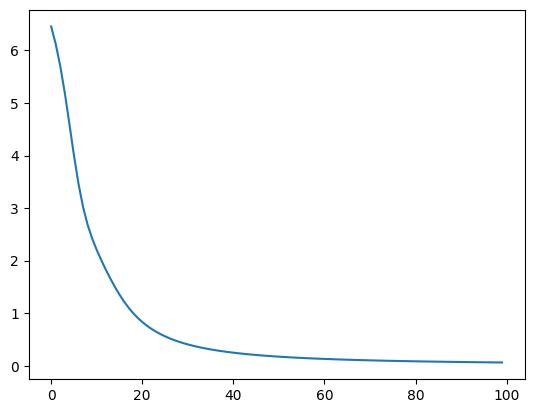

In [144]:
# plot the losses

plt.plot(losses)